# C9f Two-Stage Pipeline — Joint Recursive
## Stage 1: Predict COGS  →  Stage 2: Predict Revenue (trong cùng 1 vòng lặp)

In [38]:
# !pip install -U lightgbm scikit-learn shap

In [ ]:
import os, warnings
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

from sklearn.inspection import PartialDependenceDisplay

os.makedirs("data/output", exist_ok=True)

TRAIN_PATH    = "data/sales.csv"
SUBMISSION_PATH = "..."     #Đường dẫn cho sales_test.csv
OUTPUT_PATH     = "data/output/submission.csv"
REGIME_START  = "2019-01-01"
HOLDOUT_START = "2022-01-01"

PALETTE = {
    "primary": "#266D77", "accent": "#C72B4C", "good": "#7FBBA1",
    "warn":    "#F4A261", "purple": "#F08080", "bg": "#F8F9FA", "text": "#1A535C",
}

In [40]:
# ─────────────────────────────────────────────
# TẢI DỮ LIỆU & CHIA TẬP
# ─────────────────────────────────────────────

df_full = pd.read_csv(TRAIN_PATH, parse_dates=["Date"])
df_full = (df_full[df_full["Date"] >= REGIME_START]
           .sort_values("Date").reset_index(drop=True))

CUTOFF       = pd.Timestamp(HOLDOUT_START)
df_train_raw = df_full[df_full["Date"] < CUTOFF].copy()
df_holdout   = df_full[df_full["Date"] >= CUTOFF].copy()

print(f"Train  : {df_train_raw['Date'].min().date()} → {df_train_raw['Date'].max().date()} ({len(df_train_raw)} ngày)")
print(f"Holdout: {df_holdout['Date'].min().date()} → {df_holdout['Date'].max().date()} ({len(df_holdout)} ngày)")

Train  : 2019-01-01 → 2021-12-31 (1096 ngày)
Holdout: 2022-01-01 → 2022-12-31 (365 ngày)


In [41]:
# ══════════════════════════════════════════════════════════════
# XÂY DỰNG ĐẶC TRƯNG
# ══════════════════════════════════════════════════════════════

def build_features(df: pd.DataFrame, drop_na: bool = False) -> pd.DataFrame:
    df = df.copy()
    yr = df["Date"].dt.year; mo = df["Date"].dt.month

    # ── Bậc 1: Lịch ──────────────────────────────────────
    df["day_of_month"]      = df["Date"].dt.day
    df["month"]             = mo
    df["day_of_week"]       = df["Date"].dt.dayofweek
    df["is_weekend"]        = df["day_of_week"].isin([5, 6]).astype(int)
    df["quarter"]           = df["Date"].dt.quarter
    df["days_to_month_end"] = (df["Date"] + pd.offsets.MonthEnd(0) - df["Date"]).dt.days
    df["is_month_end"]      = (df["days_to_month_end"] <= 2).astype(int)
    df["is_month_start"]    = (df["day_of_month"] <= 3).astype(int)
    df["sin_month"]         = np.sin(2 * np.pi * mo / 12)
    df["cos_month"]         = np.cos(2 * np.pi * mo / 12)
    df["sin_dow"]           = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["cos_dow"]           = np.cos(2 * np.pi * df["day_of_week"] / 7)

    # ── Bậc 2: COGS (lag + trung bình trượt) ────────────────────────
    df["COGS_raw"]           = df["COGS"]
    for lag in [1, 7, 14, 30]:
        df[f"COGS_lag_{lag}"] = df["COGS"].shift(lag)
    cs = df["COGS"].shift(1)
    df["COGS_roll_mean_7"]   = cs.rolling(7).mean()
    df["COGS_roll_mean_30"]  = cs.rolling(30).mean()
    df["COGS_roll_mean_90"]  = cs.rolling(90).mean()
    df["COGS_roll_std_30"]   = cs.rolling(30).std()
    df["cogs_momentum"]      = df["COGS_lag_7"] / df["COGS_lag_30"].replace(0, np.nan)
    df["is_cogs_risk_month"] = mo.isin([7, 8, 11, 12]).astype(int)

    # ── Bậc 3: Lag doanh thu ──────────────────────────────────
    for lag in [1, 7, 14, 30, 60, 90]:
        df[f"Revenue_lag_{lag}"] = df["Revenue"].shift(lag)
    df["Revenue_lag_364"]       = df["Revenue"].shift(364)
    df["Revenue_lag_365"]       = df["Revenue"].shift(365)
    rs = df["Revenue"].shift(1)
    df["Revenue_roll_mean_7"]   = rs.rolling(7).mean()
    df["Revenue_roll_mean_30"]  = rs.rolling(30).mean()
    df["Revenue_roll_mean_90"]  = rs.rolling(90).mean()
    df["Revenue_roll_mean_365"] = rs.rolling(365).mean()
    df["Revenue_roll_std_30"]   = rs.rolling(30).std()
    df["Revenue_wow"]           = df["Revenue"].shift(1) / df["Revenue"].shift(8) - 1
    df["Revenue_mom"]           = df["Revenue"].shift(1) / df["Revenue"].shift(31) - 1
    df["rev_momentum"]          = df["Revenue"].shift(1) / df["Revenue"].shift(7).replace(0, np.nan)

    # ── Bậc 4: Xu hướng ─────────────────────────────────────────
    origin = pd.Timestamp(REGIME_START)
    df["time_index"]      = (df["Date"] - origin).dt.days
    df["rev_vs_baseline"] = df["Revenue"].shift(1) / df["Revenue_roll_mean_365"]

    # ── Bậc 5: Chu kỳ 2 năm (đặc trưng cốt lõi C9f) ───────────────────
    df["year_parity"]        = yr % 2
    df["aug_even"]           = ((mo == 8) & (yr % 2 == 0)).astype(int)
    df["COGS_lag_365"]       = df["COGS"].shift(365)
    df["cogs_ratio_lag_365"] = df["COGS"].shift(365) / df["Revenue"].shift(365).replace(0, np.nan)
    df["Revenue_lag_730"]    = df["Revenue"].shift(730)
    df["COGS_lag_730"]       = df["COGS"].shift(730)
    df["cogs_ratio_lag_730"] = df["COGS"].shift(730) / df["Revenue"].shift(730).replace(0, np.nan)
    df["rev_lag730_vs_365"]  = df["Revenue"].shift(730) / df["Revenue"].shift(365).replace(0, np.nan)

    # ── Bậc 6: Tỷ lệ phái sinh ────────────────────────────────
    df["cogs_yoy_ratio"]         = df["COGS_raw"] / df["COGS_lag_365"].replace(0, np.nan)
    df["rev_cogs_ratio_lag365"]  = df["Revenue_lag_365"] / df["COGS_lag_365"].replace(0, np.nan)

    # Clip tỷ lệ → tránh inf khi mẫu số gần 0
    ratio_cols = [
        "cogs_ratio_lag_365", "cogs_ratio_lag_730", "rev_lag730_vs_365",
        "rev_vs_baseline", "cogs_yoy_ratio", "rev_cogs_ratio_lag365",
        "cogs_momentum", "rev_momentum",
    ]
    for col in ratio_cols:
        if col in df.columns:
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)

    if drop_na:
        n = len(df); df = df.dropna().reset_index(drop=True)
        print(f"  Đã bỏ burn-in: {n - len(df)} hàng → còn {len(df)} hàng")
    return df


# ── Danh sách đặc trưng ─────────────────────────────────────────────

# Stage 1 — Mô hình COGS
# LƯU Ý: dùng lag Doanh thu từ dự báo đệ quy (không phải test data)
COGS_FEATURES = [
    "day_of_month", "month", "day_of_week", "is_weekend", "quarter",
    "days_to_month_end", "is_month_end", "is_month_start", "sin_month", "cos_month",
    "COGS_lag_1", "COGS_lag_7", "COGS_lag_14", "COGS_lag_30",
    "COGS_roll_mean_7", "COGS_roll_mean_30", "COGS_roll_mean_90", "COGS_roll_std_30",
    "cogs_momentum", "COGS_lag_365", "COGS_lag_730",
    "cogs_ratio_lag_365", "cogs_ratio_lag_730",
    "Revenue_lag_1", "Revenue_lag_7", "Revenue_lag_14", "Revenue_lag_30",
    "Revenue_roll_mean_7", "Revenue_roll_mean_30", "Revenue_roll_mean_90",
    "Revenue_lag_365", "Revenue_lag_730", "rev_lag730_vs_365", "rev_momentum",
    "year_parity", "is_cogs_risk_month", "aug_even", "time_index",
]

# Stage 2 — Mô hình Doanh thu (COGS_raw = COGS đã dự báo từ Stage 1)
ALL_FEATURES = [
    "day_of_month", "month", "day_of_week", "is_weekend", "quarter",
    "days_to_month_end", "is_month_end", "is_month_start", "sin_month", "cos_month",
    "sin_dow", "cos_dow",
    "COGS_raw", "COGS_lag_1", "COGS_lag_7", "COGS_lag_14", "COGS_lag_30",
    "COGS_roll_mean_7", "COGS_roll_mean_30", "is_cogs_risk_month",
    "Revenue_lag_1", "Revenue_lag_7", "Revenue_lag_14", "Revenue_lag_30",
    "Revenue_lag_60", "Revenue_lag_90", "Revenue_lag_364", "Revenue_lag_365",
    "Revenue_roll_mean_7", "Revenue_roll_mean_30", "Revenue_roll_mean_90",
    "Revenue_roll_mean_365", "Revenue_roll_std_30", "Revenue_wow", "Revenue_mom",
    "time_index", "rev_vs_baseline",
    "year_parity", "aug_even", "COGS_lag_365", "cogs_ratio_lag_365",
    "Revenue_lag_730", "COGS_lag_730", "cogs_ratio_lag_730", "rev_lag730_vs_365",
    "cogs_yoy_ratio", "rev_cogs_ratio_lag365", "rev_momentum",
]

BIENNIAL_FEATURES = {
    "year_parity", "aug_even", "COGS_lag_365", "cogs_ratio_lag_365",
    "Revenue_lag_730", "COGS_lag_730", "cogs_ratio_lag_730", "rev_lag730_vs_365",
}

TARGET_REVENUE = "Revenue"
TARGET_COGS    = "COGS"

print(f"COGS model features  : {len(COGS_FEATURES)}")
print(f"Revenue model features: {len(ALL_FEATURES)}")

COGS model features  : 38
Revenue model features: 48


In [42]:
# ─────────────────────────────────────────────
# CHUẨN BỊ DỮ LIỆU — điền median chỉ từ tập train
# ─────────────────────────────────────────────

def load_with_median_fill(path: str, cutoff: pd.Timestamp = None) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=["Date"])
    df = (df[df["Date"] >= REGIME_START]
          .sort_values("Date").reset_index(drop=True))
    df = build_features(df, drop_na=False)
    fill_source = df[df["Date"] < cutoff] if cutoff is not None else df
    all_cols = list(set(COGS_FEATURES + ALL_FEATURES))
    for col in all_cols:
        if col in df.columns:
            df[col] = df[col].fillna(fill_source[col].median())
    na_left = df[all_cols].isna().sum().sum()
    print(f"NaN còn lại sau khi điền median: {na_left}")
    return df

df_prepared   = load_with_median_fill(TRAIN_PATH, cutoff=CUTOFF)
df_train_feat = df_prepared[df_prepared["Date"] < CUTOFF].copy()
print(f"Số hàng tập huấn luyện: {len(df_train_feat)}")

NaN còn lại sau khi điền median: 0
Số hàng tập huấn luyện: 1096


In [43]:
# ─────────────────────────────────────────────
# THAM SỐ LGBM
# num_leaves=127 (so với 63 trước) — hiệu quả hơn với 48 đặc trưng
# n_estimators xác định qua early stopping — không cố định cứng
# ─────────────────────────────────────────────

LGBM_PARAMS = {
    "objective":         "regression",
    "metric":            "mae",
    "learning_rate":     0.03,
    "num_leaves":        127,
    "min_child_samples": 20,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "reg_alpha":         0.1,
    "reg_lambda":        0.1,
    "random_state":      42,
    "verbose":           -1,
    "n_jobs":            -1,
}

# Tách tập validation cho early stopping (không phải holdout)
VAL_CUT = pd.Timestamp("2021-07-01")
df_tr2  = df_train_feat[df_train_feat["Date"] < VAL_CUT]
df_vl2  = df_train_feat[df_train_feat["Date"] >= VAL_CUT]
print(f"Early stopping — train: {len(df_tr2)}  val: {len(df_vl2)}")

Early stopping — train: 912  val: 184


In [44]:
# ══════════════════════════════════════════════════════════════
# STAGE 1 — MÔ HÌNH COGS
# n_estimators xác định qua early stopping
# ══════════════════════════════════════════════════════════════

# Tìm n tối ưu qua early stopping
_mc_es = lgb.LGBMRegressor(**LGBM_PARAMS, n_estimators=3000)
_mc_es.fit(df_tr2[COGS_FEATURES], df_tr2[TARGET_COGS],
           eval_set=[(df_vl2[COGS_FEATURES], df_vl2[TARGET_COGS])],
           callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
N_COGS = _mc_es.best_iteration_
print(f"COGS — n_estimators tối ưu = {N_COGS}")

# Huấn luyện trên toàn bộ tập train
cogs_model = lgb.LGBMRegressor(**LGBM_PARAMS, n_estimators=N_COGS)
cogs_model.fit(df_train_feat[COGS_FEATURES], df_train_feat[TARGET_COGS])
print(f"Mô hình COGS đã huấn luyện: {len(COGS_FEATURES)} đặc trưng")

COGS — n_estimators tối ưu = 124
Mô hình COGS đã huấn luyện: 38 đặc trưng


In [45]:
# ══════════════════════════════════════════════════════════════
# STAGE 2 — MÔ HÌNH DOANH THU
# ══════════════════════════════════════════════════════════════

_mr_es = lgb.LGBMRegressor(**LGBM_PARAMS, n_estimators=3000)
_mr_es.fit(df_tr2[ALL_FEATURES], df_tr2[TARGET_REVENUE],
           eval_set=[(df_vl2[ALL_FEATURES], df_vl2[TARGET_REVENUE])],
           callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
N_REV = _mr_es.best_iteration_
print(f"Doanh thu — n_estimators tối ưu = {N_REV}")

revenue_model = lgb.LGBMRegressor(**LGBM_PARAMS, n_estimators=N_REV)
revenue_model.fit(df_train_feat[ALL_FEATURES], df_train_feat[TARGET_REVENUE])
print(f"Mô hình Doanh thu đã huấn luyện: {len(ALL_FEATURES)} đặc trưng")

Doanh thu — n_estimators tối ưu = 391
Mô hình Doanh thu đã huấn luyện: 48 đặc trưng


In [46]:
# ══════════════════════════════════════════════════════════════
# DỰ BÁO ĐỆ QUY SONG SONG
# Mỗi ngày: dự báo COGS trước → điền vào df_combined
#           → xây dựng lại đặc trưng → dự báo Doanh thu
# Thay vì hai vòng lặp riêng, cả hai chạy trong cùng một vòng lặp.
# Lag Doanh thu trong COGS_FEATURES lấy từ giá trị đã dự báo (không phải test data).
# ══════════════════════════════════════════════════════════════

def predict_joint_recursive(cogs_model, revenue_model,
                             df_train_raw: pd.DataFrame,
                             df_holdout: pd.DataFrame) -> pd.DataFrame:
    # Khởi tạo df kết hợp — COGS và Doanh thu của test đều là NaN
    df_blank            = df_holdout[["Date"]].copy()
    df_blank["COGS"]    = np.nan
    df_blank["Revenue"] = np.nan

    df_combined = (pd.concat([df_train_raw[["Date", "Revenue", "COGS"]], df_blank],
                              ignore_index=True)
                   .sort_values("Date").reset_index(drop=True))

    test_dates   = df_holdout["Date"].tolist()
    cogs_preds   = []
    rev_preds    = []

    for i, date in enumerate(test_dates):
        # ── Bước 1: Dự báo COGS ──────────────────────────────
        # Revenue_lag_1 = Doanh thu ngày hôm qua (đã dự báo) ← từ df_combined
        df_feat  = build_features(df_combined, drop_na=False)
        ri       = df_feat[df_feat["Date"] == date].index
        if len(ri) == 0:
            cogs_preds.append(np.nan); rev_preds.append(np.nan); continue

        row_c = df_feat.loc[ri, COGS_FEATURES].copy()
        for col in COGS_FEATURES:
            if row_c[col].isna().any():
                row_c[col] = row_c[col].fillna(df_feat[col].median())
        cp = max(cogs_model.predict(row_c)[0], 0)

        # Điền COGS đã dự báo vào df_combined
        dc_idx = df_combined[df_combined["Date"] == date].index
        df_combined.loc[dc_idx, "COGS"] = cp

        # ── Bước 2: Xây dựng lại đặc trưng với COGS vừa dự báo ─────
        # COGS_raw ngày hôm nay = cp (dự báo, không phải test data)
        df_feat2 = build_features(df_combined, drop_na=False)
        row_r    = df_feat2.loc[df_feat2["Date"] == date, ALL_FEATURES].copy()
        for col in ALL_FEATURES:
            if row_r[col].isna().any():
                row_r[col] = row_r[col].fillna(df_feat2[col].median())
        rp = max(revenue_model.predict(row_r)[0], 0)

        # Điền Doanh thu đã dự báo để ngày tiếp theo có thể dùng
        df_combined.loc[dc_idx, "Revenue"] = rp
        cogs_preds.append(cp); rev_preds.append(rp)

        if (i + 1) % 100 == 0:
            print(f"  Ngày {i + 1}/{len(test_dates)}")

    pred_df = pd.DataFrame({
        "COGS_pred":    cogs_preds,
        "Revenue_pred": rev_preds,
    }, index=test_dates)
    pred_df.index = pd.to_datetime(pred_df.index)
    pred_df.index.name = "Date"
    pred_df["COGS_true"]    = df_holdout.set_index("Date")["COGS"]
    pred_df["Revenue_true"] = df_holdout.set_index("Date")["Revenue"]
    pred_df["horizon_day"]  = range(1, len(pred_df) + 1)
    pred_df["rev_abserr"]   = (pred_df["Revenue_pred"] - pred_df["Revenue_true"]).abs()
    pred_df["cogs_abserr"]  = (pred_df["COGS_pred"]    - pred_df["COGS_true"]).abs()
    pred_df["rev_pcterr"]   = pred_df["rev_abserr"] / pred_df["Revenue_true"] * 100
    return pred_df

print("Đang chạy dự báo đệ quy song song trên holdout...")
pred_df = predict_joint_recursive(cogs_model, revenue_model, df_train_raw, df_holdout)

Đang chạy dự báo đệ quy song song trên holdout...
  Ngày 100/365
  Ngày 200/365
  Ngày 300/365


In [47]:
# ─────────────────────────────────────────────
# ĐÁNH GIÁ
# ─────────────────────────────────────────────

valid = pred_df.dropna()

# Chỉ số đánh giá COGS
cogs_mae  = valid["cogs_abserr"].mean()
cogs_rmse = np.sqrt((valid["cogs_abserr"] ** 2).mean())
cogs_r2   = 1 - (valid["cogs_abserr"] ** 2).sum() / (
            (valid["COGS_true"] - valid["COGS_true"].mean()) ** 2).sum()

# Chỉ số đánh giá Doanh thu
mae  = valid["rev_abserr"].mean()
rmse = np.sqrt((valid["rev_abserr"] ** 2).mean())
mape = valid["rev_pcterr"].mean()
r2   = 1 - (valid["rev_abserr"] ** 2).sum() / (
       (valid["Revenue_true"] - valid["Revenue_true"].mean()) ** 2).sum()
corr = valid[["horizon_day", "rev_abserr"]].corr().iloc[0, 1]

print("=" * 52)
print("STAGE 1 — Mô hình COGS (Holdout)")
print(f"  MAE  : {cogs_mae:>12,.0f} VND  R²: {cogs_r2:.4f}")
print(f"  RMSE : {cogs_rmse:>12,.0f} VND")
print("=" * 52)
print("STAGE 2 — Mô hình Doanh thu (Holdout)")
print(f"  MAE  : {mae:>12,.0f} VND")
print(f"  RMSE : {rmse:>12,.0f} VND")
print(f"  MAPE : {mape:>11.2f}%")
print(f"  R²   : {r2:>12.4f}")
print(f"  Corr(horizon, error): {corr:+.4f}",
      "→ không tích lũy sai số" if abs(corr) < 0.1 else
      "→ tích lũy sai số yếu" if abs(corr) < 0.3 else "→ tích lũy sai số mạnh")
print("=" * 52)

# Phân tích theo tháng
valid2            = valid.copy()
valid2["bucket"]  = (valid2["horizon_day"] - 1) // 30 + 1
monthly_mae       = valid2.groupby("bucket")["rev_abserr"].mean()
print("\nMAE Doanh thu theo tháng:")
for bkt, mv in monthly_mae.items():
    flag = " ← ĐỘT BIẾN" if mv > mae * 1.3 else ""
    print(f"  M{bkt:>2} (ngày {(bkt-1)*30+1:>3}–{bkt*30:<3}): {mv:>10,.0f}{flag}")

STAGE 1 — Mô hình COGS (Holdout)
  MAE  :      590,568 VND  R²: 0.6891
  RMSE :      813,277 VND
STAGE 2 — Mô hình Doanh thu (Holdout)
  MAE  :      649,861 VND
  RMSE :      905,342 VND
  MAPE :       21.52%
  R²   :       0.7074
  Corr(horizon, error): -0.1442 → tích lũy sai số yếu

MAE Doanh thu theo tháng:
  M 1 (ngày   1–30 ):    402,126
  M 2 (ngày  31–60 ):    826,834
  M 3 (ngày  61–90 ):    948,383 ← ĐỘT BIẾN
  M 4 (ngày  91–120):    718,163
  M 5 (ngày 121–150):    878,317 ← ĐỘT BIẾN
  M 6 (ngày 151–180):    638,892
  M 7 (ngày 181–210):    504,275
  M 8 (ngày 211–240):    842,414
  M 9 (ngày 241–270):    859,130 ← ĐỘT BIẾN
  M10 (ngày 271–300):    424,732
  M11 (ngày 301–330):    434,041
  M12 (ngày 331–360):    356,109
  M13 (ngày 361–390):    439,361


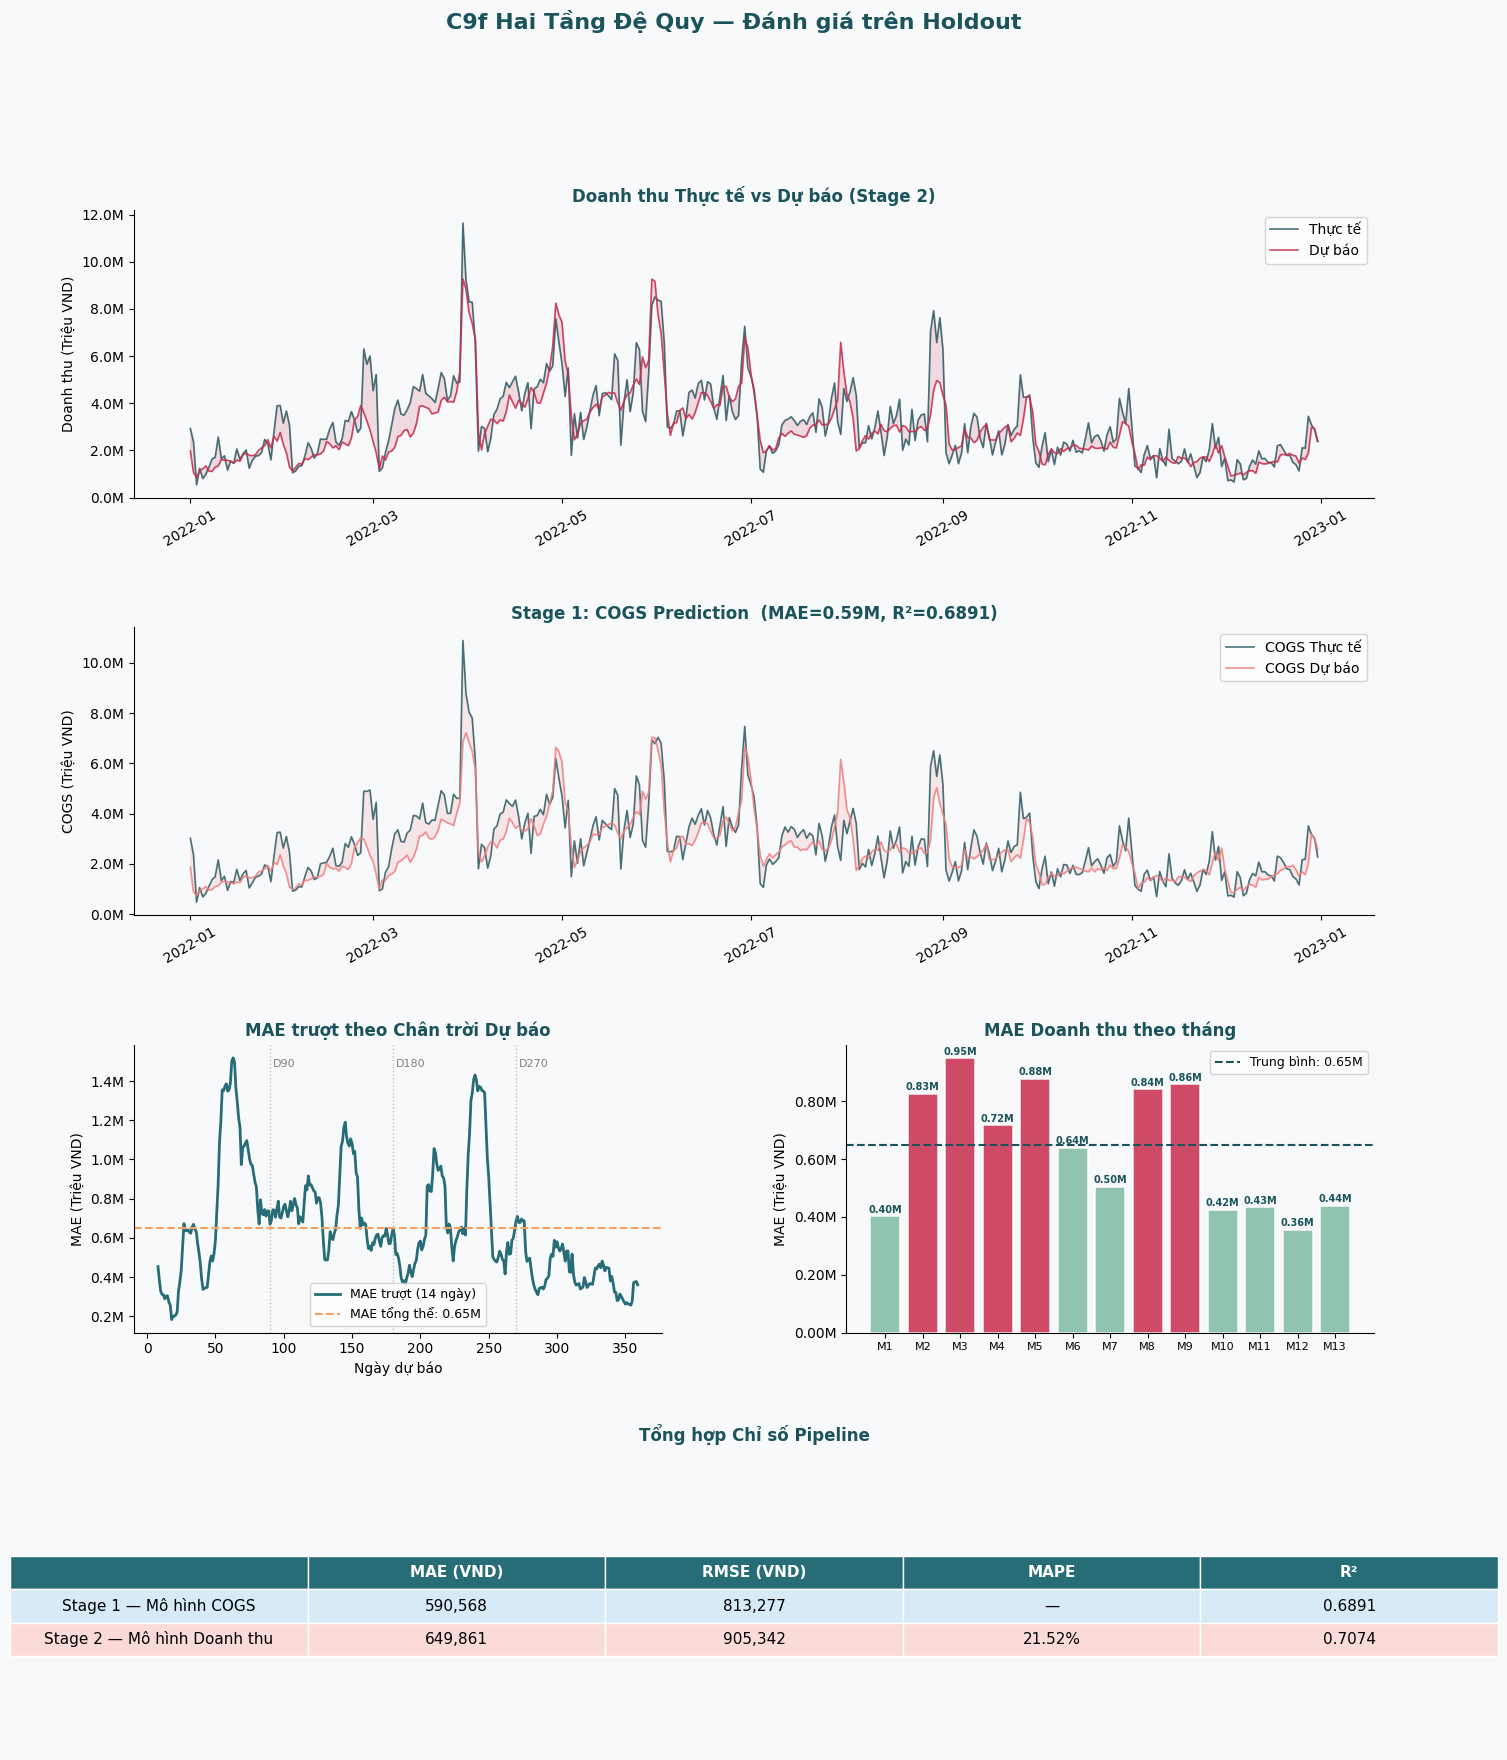

Saved → data/output/c9f_overview.png


In [48]:
# ─────────────────────────────────────────────
# TRỰC QUAN HÓA
# ─────────────────────────────────────────────

fig = plt.figure(figsize=(16, 20))
fig.patch.set_facecolor(PALETTE["bg"])
fig.suptitle("C9f Hai Tầng Đệ Quy — Đánh giá trên Holdout",
             fontsize=16, fontweight="bold", color=PALETTE["text"], y=0.98)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(PALETTE["bg"])
ax1.plot(valid.index, valid["Revenue_true"]/1e6, color=PALETTE["text"], lw=1.2, alpha=0.8, label="Thực tế")
ax1.plot(valid.index, valid["Revenue_pred"]/1e6, color=PALETTE["accent"], lw=1.2, alpha=0.85, label="Dự báo")
ax1.fill_between(valid.index, valid["Revenue_true"]/1e6, valid["Revenue_pred"]/1e6,
                 alpha=0.15, color=PALETTE["accent"])
ax1.set_title("Doanh thu Thực tế vs Dự báo (Stage 2)", fontweight="bold", color=PALETTE["text"])
ax1.set_ylabel("Doanh thu (Triệu VND)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax1.legend(); ax1.spines[["top","right"]].set_visible(False)
ax1.tick_params(axis="x", rotation=30)

ax2 = fig.add_subplot(gs[1, :])
ax2.set_facecolor(PALETTE["bg"])
ax2.plot(valid.index, valid["COGS_true"]/1e6, color=PALETTE["text"], lw=1.2, alpha=0.8, label="COGS Thực tế")
ax2.plot(valid.index, valid["COGS_pred"]/1e6, color=PALETTE["purple"], lw=1.2, alpha=0.85, label="COGS Dự báo")
ax2.fill_between(valid.index, valid["COGS_true"]/1e6, valid["COGS_pred"]/1e6, alpha=0.15, color=PALETTE["purple"])
ax2.set_title(f"Stage 1: COGS Prediction  (MAE={cogs_mae/1e6:.2f}M, R²={cogs_r2:.4f})",
              fontweight="bold", color=PALETTE["text"])
ax2.set_ylabel("COGS (Triệu VND)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax2.legend(); ax2.spines[["top","right"]].set_visible(False)
ax2.tick_params(axis="x", rotation=30)

ax3 = fig.add_subplot(gs[2, 0])
ax3.set_facecolor(PALETTE["bg"])
rolling_mae = valid["rev_abserr"].rolling(14, center=True).mean()
ax3.plot(valid["horizon_day"], rolling_mae/1e6, color=PALETTE["primary"], lw=2, label="MAE trượt (14 ngày)")
ax3.axhline(mae/1e6, color=PALETTE["warn"], ls="--", lw=1.5, label=f"MAE tổng thể: {mae/1e6:.2f}M")
for day in [90, 180, 270]:
    ax3.axvline(day, color="gray", ls=":", lw=1, alpha=0.5)
    ax3.text(day+2, 0.95, f"D{day}", fontsize=8, color="gray",
             transform=ax3.get_xaxis_transform(), va="top")
ax3.set_title("MAE trượt theo Chân trời Dự báo", fontweight="bold", color=PALETTE["text"])
ax3.set_xlabel("Ngày dự báo"); ax3.set_ylabel("MAE (Triệu VND)")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax3.legend(fontsize=9); ax3.spines[["top","right"]].set_visible(False)

ax4 = fig.add_subplot(gs[2, 1])
ax4.set_facecolor(PALETTE["bg"])
bar_colors = [PALETTE["good"] if v <= mae else PALETTE["accent"] for v in monthly_mae.values]
bars = ax4.bar([f"M{b}" for b in monthly_mae.index], monthly_mae.values/1e6,
               color=bar_colors, alpha=0.85, edgecolor="white", linewidth=1.2)
ax4.axhline(mae/1e6, color=PALETTE["text"], ls="--", lw=1.5, label=f"Trung bình: {mae/1e6:.2f}M")
for bar, val in zip(bars, monthly_mae.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f"{val/1e6:.2f}M", ha="center", va="bottom", fontsize=7,
             fontweight="bold", color=PALETTE["text"])
ax4.set_title("MAE Doanh thu theo tháng", fontweight="bold", color=PALETTE["text"])
ax4.set_ylabel("MAE (Triệu VND)")
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}M"))
ax4.legend(fontsize=9); ax4.spines[["top","right"]].set_visible(False)
ax4.tick_params(axis="x", labelsize=8)

ax5 = fig.add_subplot(gs[3, :])
ax5.set_facecolor(PALETTE["bg"]); ax5.axis("off")
tbl_data = [
    ["", "MAE (VND)", "RMSE (VND)", "MAPE", "R²"],
    ["Stage 1 — Mô hình COGS",    f"{cogs_mae:,.0f}", f"{cogs_rmse:,.0f}", "—",             f"{cogs_r2:.4f}"],
    ["Stage 2 — Mô hình Doanh thu", f"{mae:,.0f}",      f"{rmse:,.0f}",      f"{mape:.2f}%",  f"{r2:.4f}"],
]
tbl = ax5.table(cellText=tbl_data[1:], colLabels=tbl_data[0], loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 2.0)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("white")
    if row == 0: cell.set_facecolor(PALETTE["primary"]); cell.set_text_props(color="white", fontweight="bold")
    elif row == 1: cell.set_facecolor("#D6EAF8")
    else: cell.set_facecolor("#FADBD8")
ax5.set_title("Tổng hợp Chỉ số Pipeline", fontweight="bold", color=PALETTE["text"], pad=15)

plt.savefig("data/output/c9f_overview.png", dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Saved → data/output/c9f_overview.png")

Đang tính SHAP — mô hình COGS...


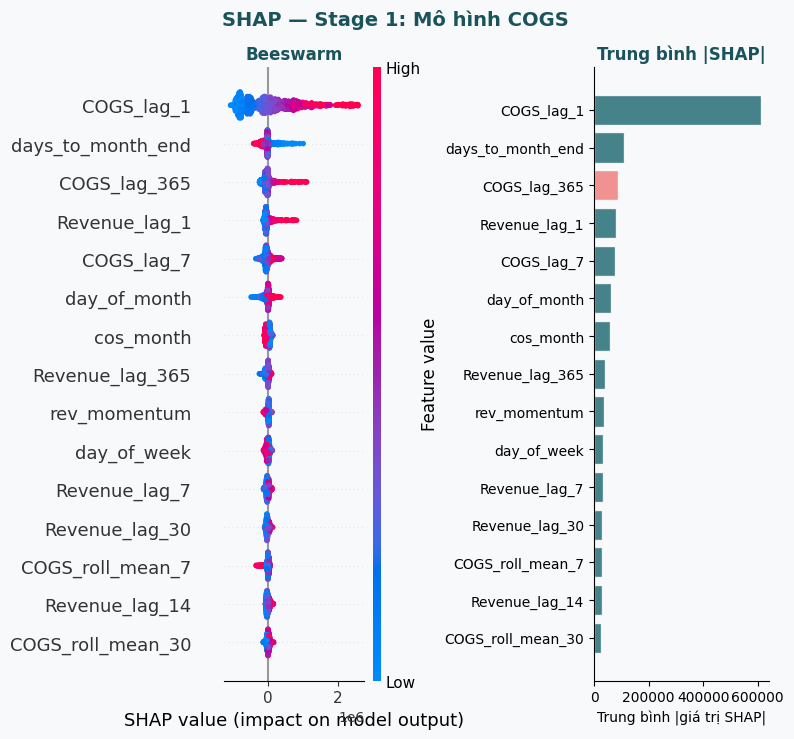

In [62]:
# ─────────────────────────────────────────────
# SHAP — Stage 1: Mô hình COGS
# ─────────────────────────────────────────────

print("Đang tính SHAP — mô hình COGS...")
explainer_cogs = shap.TreeExplainer(cogs_model)
shap_cogs      = explainer_cogs.shap_values(df_train_feat[COGS_FEATURES])
shap_cogs_mean = (pd.DataFrame({"feature": COGS_FEATURES,
                                 "mean_shap": np.abs(shap_cogs).mean(axis=0)})
                  .sort_values("mean_shap", ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(PALETTE["bg"])
fig.suptitle("SHAP — Stage 1: Mô hình COGS", fontsize=14, fontweight="bold", color=PALETTE["text"])

plt.sca(axes[0]); axes[0].set_facecolor(PALETTE["bg"])
shap.summary_plot(shap_cogs, df_train_feat[COGS_FEATURES], max_display=15, show=False)
axes[0].set_title("Beeswarm", fontweight="bold", color=PALETTE["text"])

top_c = shap_cogs_mean.head(15)
cogs_biennial = {"COGS_lag_365","COGS_lag_730","cogs_ratio_lag_365","cogs_ratio_lag_730","year_parity","aug_even"}
colors_c = [PALETTE["purple"] if f in cogs_biennial else PALETTE["primary"] for f in top_c["feature"]]
axes[1].set_facecolor(PALETTE["bg"])
axes[1].barh(top_c["feature"][::-1], top_c["mean_shap"][::-1], color=colors_c[::-1], alpha=0.85, edgecolor="white")
axes[1].set_title("Trung bình |SHAP|", fontweight="bold", color=PALETTE["text"])
axes[1].set_xlabel("Trung bình |giá trị SHAP|"); axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("data/output/c9f_shap_cogs.png", dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()

Đang tính SHAP — mô hình Doanh thu...


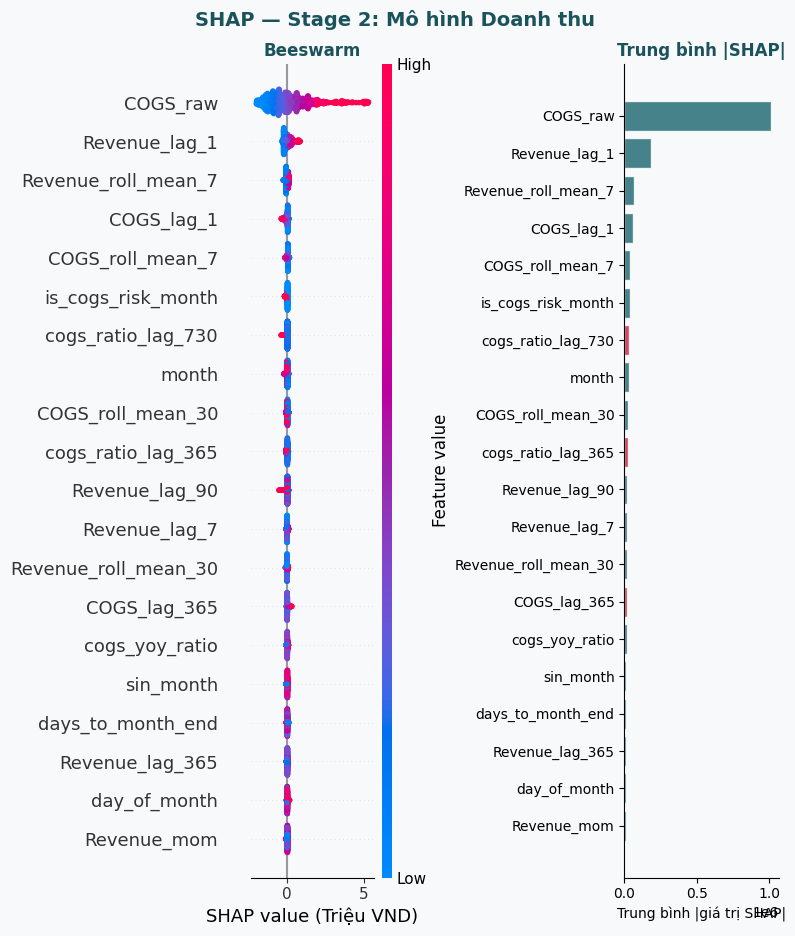


Top 10 đặc trưng Doanh thu:
  COGS_raw                       1,015,906.7
  Revenue_lag_1                   181,721.7
  Revenue_roll_mean_7              67,291.5
  COGS_lag_1                       58,882.7
  COGS_roll_mean_7                 37,541.1
  is_cogs_risk_month               35,251.8
  cogs_ratio_lag_730               32,024.4 ← chu kỳ 2 năm
  month                            30,597.0
  COGS_roll_mean_30                25,759.1
  cogs_ratio_lag_365               21,938.6 ← chu kỳ 2 năm


In [67]:
# ─────────────────────────────────────────────
# SHAP — Stage 2: Mô hình Doanh thu
# ─────────────────────────────────────────────

print("Đang tính SHAP — mô hình Doanh thu...")
explainer_rev = shap.TreeExplainer(revenue_model)
shap_rev      = explainer_rev.shap_values(df_train_feat[ALL_FEATURES])
shap_rev_mean = (pd.DataFrame({"feature": ALL_FEATURES,
                                "mean_shap": np.abs(shap_rev).mean(axis=0)})
                 .sort_values("mean_shap", ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor(PALETTE["bg"])
fig.suptitle("SHAP — Stage 2: Mô hình Doanh thu", fontsize=14, fontweight="bold", color=PALETTE["text"])

plt.sca(axes[0]); axes[0].set_facecolor(PALETTE["bg"])
shap_rev_M = shap_rev / 1e6  # toàn bộ array chia 1e6
shap.summary_plot(shap_rev_M, df_train_feat[ALL_FEATURES],
                  max_display=20, show=False)
plt.gca().set_xlabel("SHAP value (Triệu VND)")
axes[0].set_title("Beeswarm", fontweight="bold", color=PALETTE["text"])


top_r = shap_rev_mean.head(20)
colors_r = [PALETTE["accent"] if f in BIENNIAL_FEATURES else PALETTE["primary"] for f in top_r["feature"]]
axes[1].set_facecolor(PALETTE["bg"])
axes[1].barh(top_r["feature"][::-1], top_r["mean_shap"][::-1], color=colors_r[::-1], alpha=0.85, edgecolor="white")
axes[1].set_title("Trung bình |SHAP|", fontweight="bold", color=PALETTE["text"])
axes[1].set_xlabel("Trung bình |giá trị SHAP|"); axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("data/output/c9f_shap_revenue.png", dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()

print("\nTop 10 đặc trưng Doanh thu:")
for _, row in shap_rev_mean.head(10).iterrows():
    tag = " ← chu kỳ 2 năm" if row["feature"] in BIENNIAL_FEATURES else ""
    print(f"  {row['feature']:<30} {row['mean_shap']:>10,.1f}{tag}")

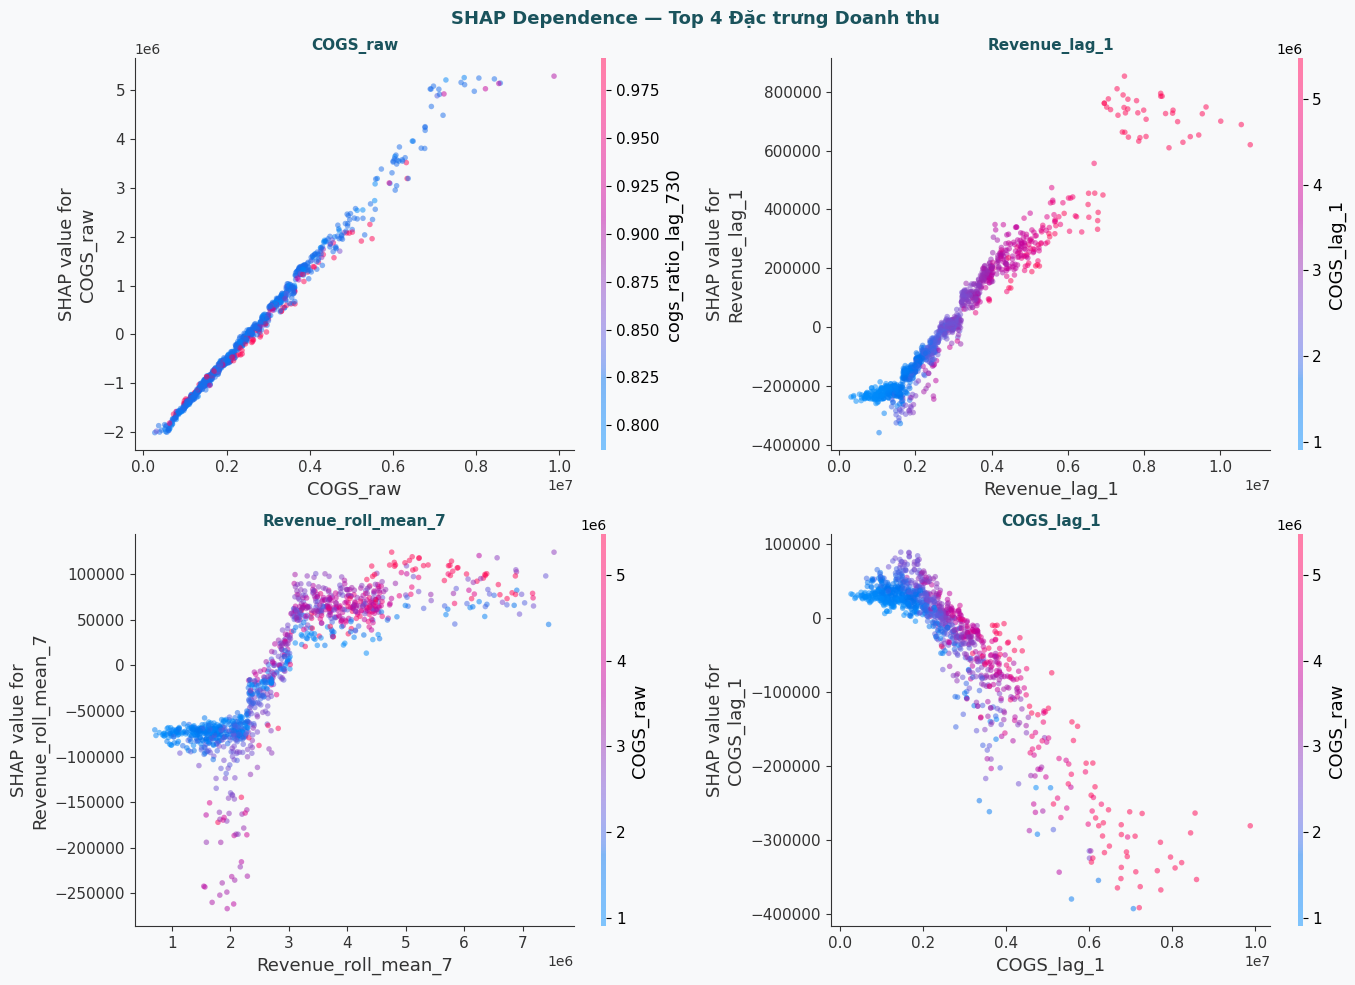

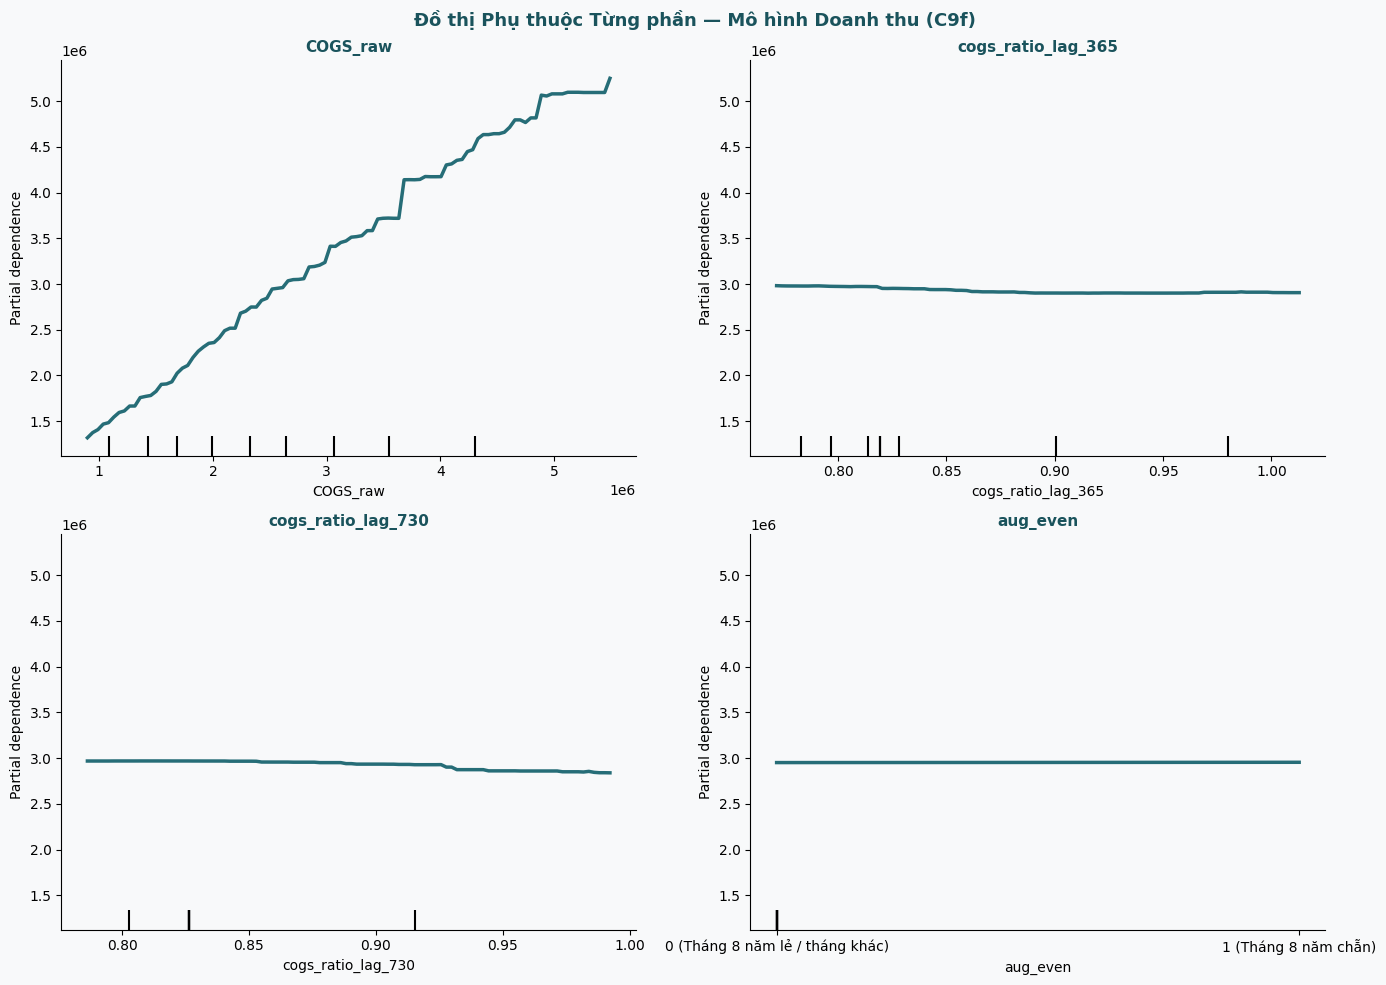

In [51]:
# ─────────────────────────────────────────────
# SHAP DEPENDENCE + ĐỒ THỊ PDP
# ─────────────────────────────────────────────

top4 = shap_rev_mean.head(4)["feature"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(PALETTE["bg"])
fig.suptitle("SHAP Dependence — Top 4 Đặc trưng Doanh thu", fontsize=13, fontweight="bold", color=PALETTE["text"])
for ax, feat in zip(axes.flat, top4):
    ax.set_facecolor(PALETTE["bg"])
    shap.dependence_plot(feat, shap_rev, df_train_feat[ALL_FEATURES], ax=ax, show=False, alpha=0.5)
    ax.set_title(feat, fontweight="bold", color=PALETTE["text"], fontsize=11)
    ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("data/output/c9f_shap_dependence.png", dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()

# ĐỒ THỊ PDP
PDP_FEATURES = ["COGS_raw", "cogs_ratio_lag_365", "cogs_ratio_lag_730", "aug_even"]
pdp_idx = [ALL_FEATURES.index(f) for f in PDP_FEATURES]
X_arr   = df_train_feat[ALL_FEATURES].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(PALETTE["bg"])
fig.suptitle("Đồ thị Phụ thuộc Từng phần — Mô hình Doanh thu (C9f)", fontsize=13, fontweight="bold", color=PALETTE["text"])
PartialDependenceDisplay.from_estimator(revenue_model, X_arr, features=pdp_idx,
    feature_names=ALL_FEATURES, kind="average", n_jobs=-1, ax=axes.flat,
    line_kw={"color": PALETTE["primary"], "lw": 2.5})
for ax, feat in zip(axes.flat, PDP_FEATURES):
    ax.set_facecolor(PALETTE["bg"]); ax.spines[["top","right"]].set_visible(False)
    ax.set_title(feat, fontweight="bold", color=PALETTE["text"], fontsize=11)
    ax.axhline(0, color="gray", ls="--", lw=1, alpha=0.6)
    if feat == "aug_even":
        ax.set_xticks([0,1]); ax.set_xticklabels(["0 (Tháng 8 năm lẻ / tháng khác)","1 (Tháng 8 năm chẵn)"])
plt.tight_layout()
plt.savefig("data/output/c9f_pdp.png", dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()

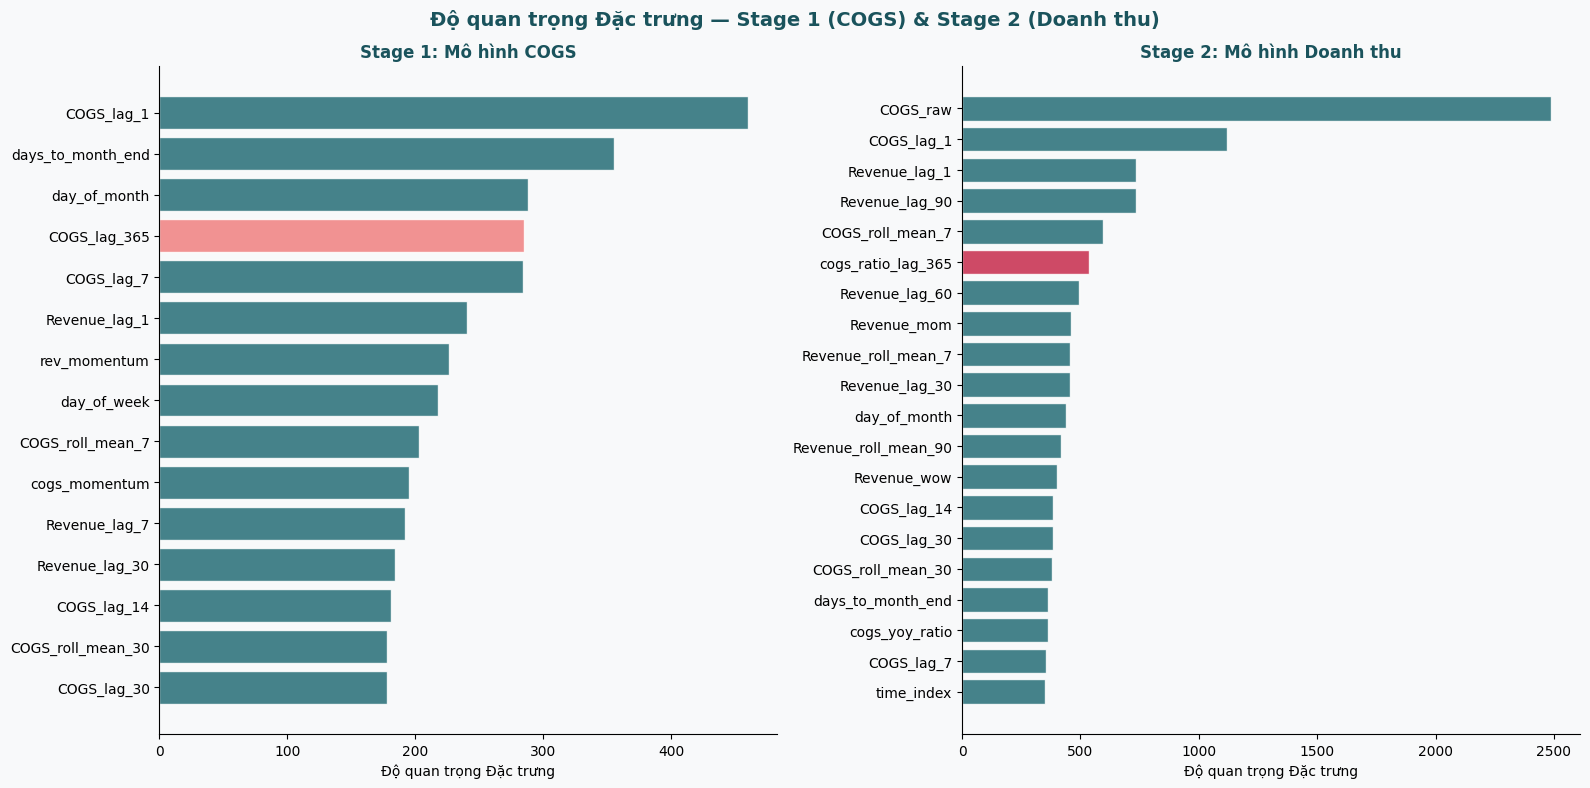

In [52]:
# ─────────────────────────────────────────────
# ĐỘ QUAN TRỌNG ĐẶC TRƯNG — cả hai mô hình
# ─────────────────────────────────────────────

fi_rev  = pd.DataFrame({"feature": ALL_FEATURES,    "importance": revenue_model.feature_importances_}).sort_values("importance", ascending=False)
fi_cogs = pd.DataFrame({"feature": COGS_FEATURES, "importance": cogs_model.feature_importances_}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor(PALETTE["bg"])
fig.suptitle("Độ quan trọng Đặc trưng — Stage 1 (COGS) & Stage 2 (Doanh thu)", fontsize=14, fontweight="bold", color=PALETTE["text"])

for ax, fi, title, biennial_set, chi in [
    (axes[0], fi_cogs.head(15), "Stage 1: Mô hình COGS",    cogs_biennial,    PALETTE["purple"]),
    (axes[1], fi_rev.head(20),  "Stage 2: Mô hình Doanh thu", BIENNIAL_FEATURES, PALETTE["accent"]),
]:
    ax.set_facecolor(PALETTE["bg"])
    colors_fi = [chi if f in biennial_set else PALETTE["primary"] for f in fi["feature"]]
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color=colors_fi[::-1], alpha=0.85, edgecolor="white")
    ax.set_title(title, fontweight="bold", color=PALETTE["text"], fontsize=12)
    ax.set_xlabel("Độ quan trọng Đặc trưng"); ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("data/output/c9f_feature_importance.png", dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()

In [ ]:
# ─────────────────────────────────────────────
# TẠO FILE NỘP BÀI
# ─────────────────────────────────────────────
df_test = pd.read_csv(SUBMISSION_PATH, parse_dates=["Date"])
df_test = df_test.sort_values("Date").reset_index(drop=True)
print(f"Tập test: {df_test['Date'].min().date()} → {df_test['Date'].max().date()} ({len(df_test)} ngày)")

# Huấn luyện mô hình CUỐI trên toàn bộ sales.csv (2019–2022)
df_full_feat = load_with_median_fill(TRAIN_PATH, cutoff=None)
df_train_full_raw = pd.read_csv(TRAIN_PATH, parse_dates=["Date"])
df_train_full_raw = (df_train_full_raw[df_train_full_raw["Date"] >= REGIME_START]
                     .sort_values("Date").reset_index(drop=True))

cogs_model_final = lgb.LGBMRegressor(**LGBM_PARAMS, n_estimators=N_COGS)
cogs_model_final.fit(df_full_feat[COGS_FEATURES], df_full_feat[TARGET_COGS])

revenue_model_final = lgb.LGBMRegressor(**LGBM_PARAMS, n_estimators=N_REV)
revenue_model_final.fit(df_full_feat[ALL_FEATURES], df_full_feat[TARGET_REVENUE])

print(f"Mô hình cuối đã huấn luyện trên {len(df_full_feat)} hàng (2019–2022)")

# Tập test — chỉ dùng cột Date, không dùng Revenue/COGS
df_test_blank = df_test[["Date"]].copy()
df_test_blank["COGS"]    = np.nan
df_test_blank["Revenue"] = np.nan

sub_df = predict_joint_recursive(cogs_model_final, revenue_model_final,
                                  df_train_full_raw, df_test_blank)

submission = sub_df[["Revenue_pred"]].reset_index()
submission.columns = ["Date", "Revenue"]
submission["Date"] = submission["Date"].dt.strftime("%Y-%m-%d")
submission.to_csv(OUTPUT_PATH, index=False)

print(f"\nFile nộp bài đã lưu → {OUTPUT_PATH}")
print(f"  Số hàng : {len(submission)}")
print(f"  Min     : {submission['Revenue'].min():,.0f}")
print(f"  Max     : {submission['Revenue'].max():,.0f}")
print(f"  Trung bình: {submission['Revenue'].mean():,.0f}")
submission.head(10)

Tập test: 2023-01-01 → 2024-07-01 (548 ngày)
NaN còn lại sau khi điền median: 0
Mô hình cuối đã huấn luyện trên 1461 hàng (2019–2022)
  Ngày 100/548
  Ngày 200/548
  Ngày 300/548
  Ngày 400/548
  Ngày 500/548

File nộp bài đã lưu → data/output/submission.csv
  Số hàng : 548
  Min     : 834,334
  Max     : 9,995,847
  Trung bình: 3,311,888


,Date,Revenue
0,2023-01-01,1.681722e+06
1,2023-01-02,1.205831e+06
2,2023-01-03,9.697267e+05
3,2023-01-04,1.165796e+06
4,2023-01-05,1.225653e+06
5,2023-01-06,1.193399e+06
6,2023-01-07,1.367212e+06
7,2023-01-08,1.535641e+06
8,2023-01-09,1.710755e+06
9,2023-01-10,1.811641e+06
